# Extrapolate SKedge nexafs to perfect molecular orientation

## Setup

### Imports

In [1]:
# Imports:
import sys
import pathlib
import numpy as np
import matplotlib.pyplot as plt
# import matplotlib as mpl
from matplotlib.ticker import MultipleLocator
import xarray as xr
import pandas as pd
import dask.array as da
# import kkcalc
# from kkcalc import data
# from kkcalc import kk
from kkcalc.models import *
from kkcalc import stoichiometry
import xraydb
from scipy import optimize
from tqdm.auto import tqdm

basePath = pathlib.Path('/Users/andrew/Library/CloudStorage/OneDrive-UCB-O365/research/data_analysis/rsoxs_suite')
nexafsFxnsPath = basePath.joinpath('misc_older_work/nexafs_analysis')
sys.path.append(str(nexafsFxnsPath))
import nexafs_fxns as nf  # custom nexafs functions used throughout this notebook

ModuleNotFoundError: No module named 'kkcalc'

### Define paths/objects

In [2]:
basePath = pathlib.Path('/Users/andrew/Library/CloudStorage/OneDrive-UCB-O365/research/data_analysis/rsoxs_suite')
nfZarrsPath = basePath.joinpath('local_data/trexs_nexafs_2024C3/waxs_all/fl_nexafs_zarrs')
lpZarrsPath = basePath.joinpath('local_data/trexs_nexafs_2024C3/waxs_all/lamella_vs_energy_zarrs')

nfZarrsPath.exists()

True

## Load and check NEXAFS data

### Load NEXAF data

In [3]:
# Define path to zarr
nfZarrPath = sorted(nfZarrsPath.glob('*.zarr'))[0]
nfZarrPath

PosixPath('/Users/andrew/Library/CloudStorage/OneDrive-UCB-O365/research/data_analysis/rsoxs_suite/local_data/trexs_nexafs_2024C3/waxs_all/fl_nexafs_zarrs/fl_nexafs_v1.zarr')

In [4]:
# Load zarr into xarray
nf_DA = xr.open_zarr(nfZarrPath)['fl_nexafs'].compute()
nf_DA = nf_DA.assign_coords({'cos_sq_theta': ('theta', np.round(((np.cos(np.deg2rad(nf_DA.theta)))**2), 5).data)})
nf_DA

<xarray.DataArray 'fl_nexafs' (sample_ID: 9, theta: 3, energy: 45)> Size: 10kB
array([[[-0.41077058, -0.22078365, -0.09513144, ...,  0.79223524,
          0.92340233,  1.07659767],
        [-0.38961043, -0.19134175, -0.08593922, ...,  0.71107445,
          0.89666805,  1.10333195],
        [-0.34402685, -0.17011382, -0.09002547, ...,  0.7819778 ,
          0.91762148,  1.08237852]],

       [[ 0.10228803,  0.04490482,  0.01953648, ...,  1.17958607,
          1.03764692,  0.96235308],
        [ 0.10915128,  0.05596543,  0.02511987, ...,  1.18744964,
          1.04508585,  0.95491415],
        [ 0.12750074,  0.06590075,  0.02672047, ...,  1.15813531,
          1.03866026,  0.96133974]],

       [[ 0.18951458,  0.08400359,  0.04673   , ...,  1.2949463 ,
          1.06346472,  0.93653528],
        [ 0.17156163,  0.10004697,  0.04187024, ...,  1.30667703,
          1.08297332,  0.91702668],
        [ 0.15791765,  0.07689307,  0.0335237 , ...,  1.3034102 ,
          1.09416705,  0.90583295]],
...
       [[ 0.14945225,  0.08195294,  0.04517896, ...,  1.34466475,
          1.07576707,  0.92423293],
        [ 0.14645657,  0.0645724 ,  0.03608419, ...,  1.32968515,
          1.0754926 ,  0.9245074 ],
        [ 0.14804235,  0.07174848,  0.03535522, ...,  1.35019004,
          1.08819968,  0.91180032]],

       [[ 0.13059418,  0.06230301,  0.03569537, ...,  1.25723169,
          1.05379416,  0.94620584],
        [ 0.13041309,  0.06037626,  0.02721031, ...,  1.27091495,
          1.07389298,  0.92610702],
        [ 0.11438393,  0.05145012,  0.02475699, ...,  1.27919868,
          1.08385719,  0.91614281]],

       [[ 0.15043043,  0.06961586,  0.03249948, ...,  1.26444866,
          1.05147112,  0.94852888],
        [ 0.1373164 ,  0.07250496,  0.03372843, ...,  1.26745804,
          1.07581778,  0.92418222],
        [ 0.14371947,  0.07094518,  0.0327005 , ...,  1.28125285,
          1.07651698,  0.92348302]]])
Coordinates:
  * energy        (energy) float64 360B 2.442e+03 2.447e+03 ... 2.517e+03
  * sample_ID     (sample_ID) <U5 180B 'SiN-0' 'SiN-1' ... 'SiN-7' 'SiN-8'
  * theta         (theta) int64 24B 90 55 35
    cos_sq_theta  (theta) float64 24B 0.0 0.329 0.671

In [5]:
# Initalize dictionaries for sample names (for titles & saving files)
sn = {
    'SiN-0': 'BareSiN',
    'SiN-1': 'PM7 CF + 0.0% CN',
    'SiN-2': 'PM7 CF + 5.0% CN',
    'SiN-3': 'PM6 CF + 0.0% CN',
    'SiN-4': 'PM6 CF + 5.0% CN',
    'SiN-5': 'PM7 CF + 1.0% CN',
    'SiN-6': 'PM7 CF + 0.5% CN',
    'SiN-7': 'PM6 CF + 1.0% CN',
    'SiN-8': 'PM6 CF + 0.5% CN',    
}

sn_id = {
    'SiN-0': 'BareSiN',
    'SiN-1': 'PM7_CF',
    'SiN-2': 'PM7_5CN-CF',
    'SiN-3': 'PM6_CF',
    'SiN-4': 'PM6_5CN-CF',
    'SiN-5': 'PM7_1CN-CF',
    'SiN-6': 'PM7_p5CN-CF',
    'SiN-7': 'PM6_1CN-CF',
    'SiN-8': 'PM6_p5CN-CF',
}

### Plot experimental data

In [6]:
whos PosixPath

Variable         Type         Data/Info
---------------------------------------
basePath         PosixPath    /Users/andrew/Library/Clo<...>data_analysis/rsoxs_suite
lpZarrsPath      PosixPath    /Users/andrew/Library/Clo<...>l/lamella_vs_energy_zarrs
nexafsFxnsPath   PosixPath    /Users/andrew/Library/Clo<...>lder_work/nexafs_analysis
nfZarrPath       PosixPath    /Users/andrew/Library/Clo<...>s_zarrs/fl_nexafs_v1.zarr
nfZarrsPath      PosixPath    /Users/andrew/Library/Clo<...>/waxs_all/fl_nexafs_zarrs


  0%|          | 0/9 [00:00<?, ?it/s]

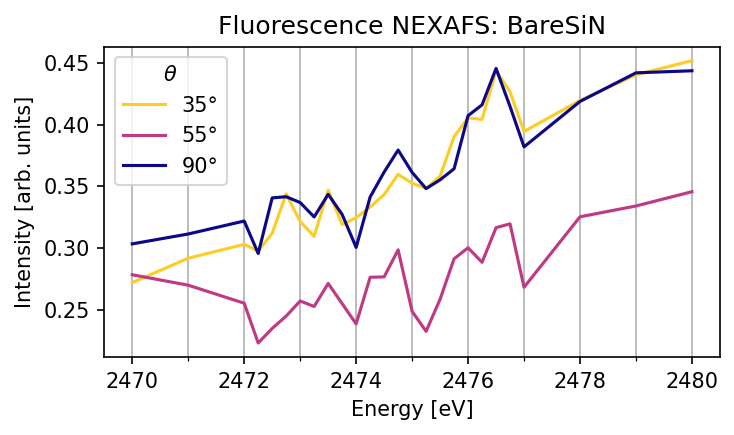

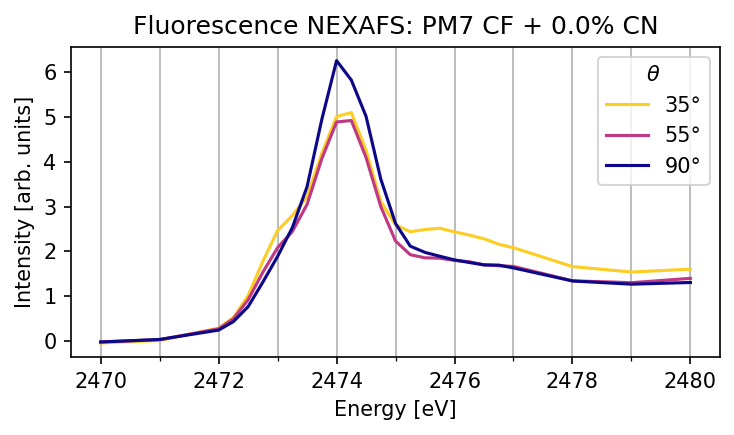

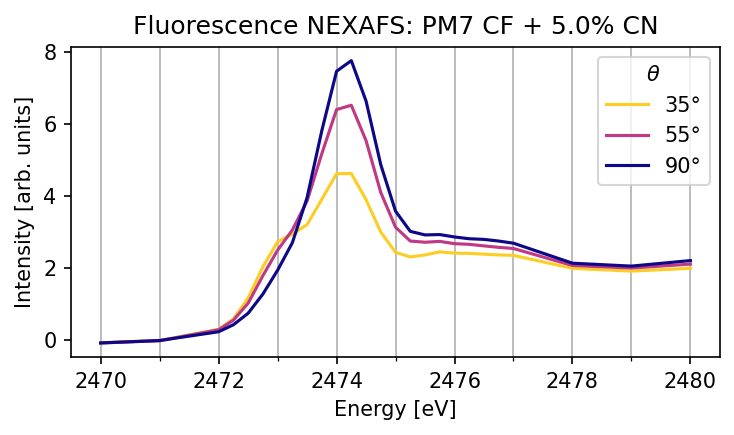

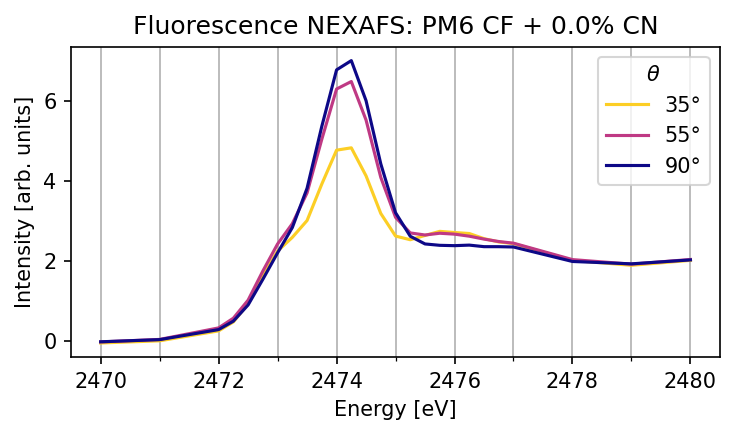

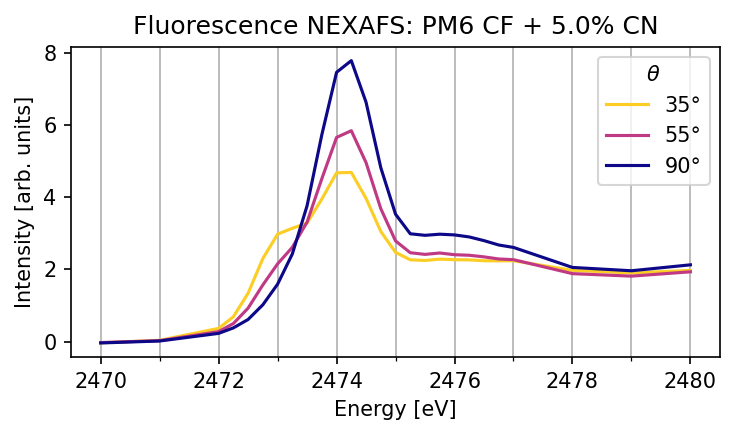

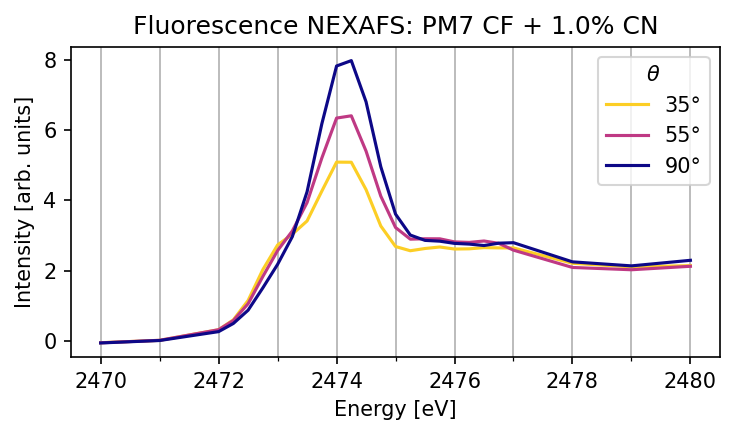

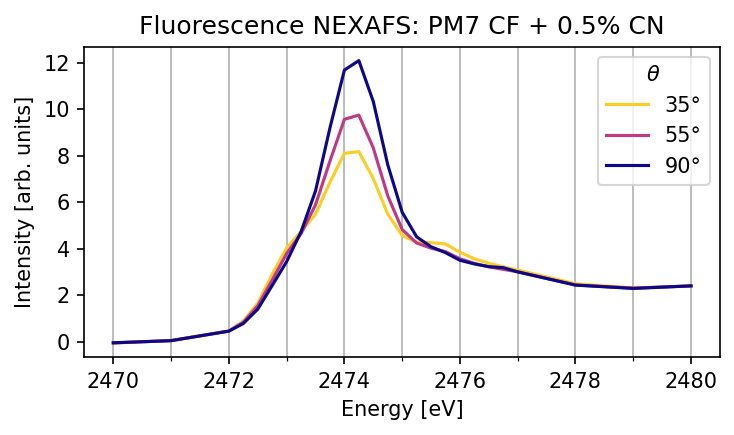

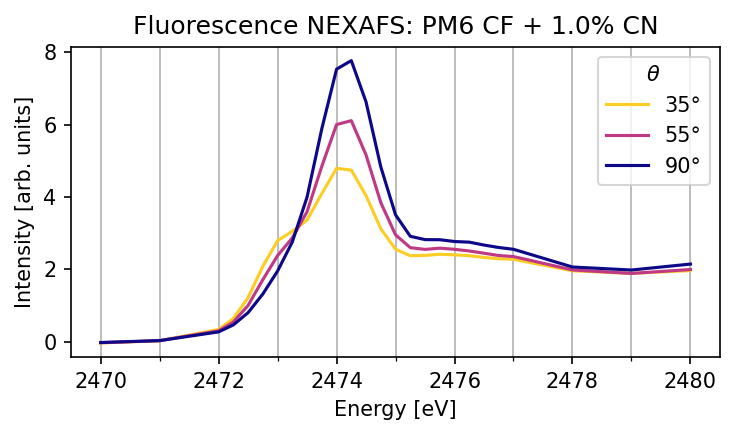

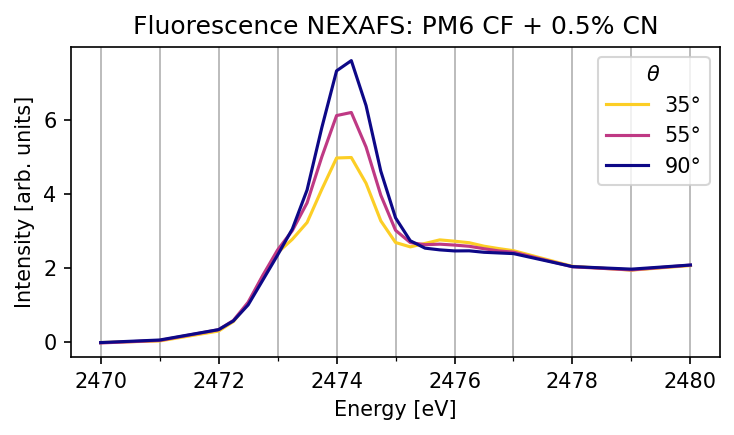

In [11]:
%matplotlib inline
plt.close('all')

# Plot all incident angles NEXAFS for each sample

# Select energy slice(s)
# e_slice = slice(None, None)
# e_slice = slice(2445, 2520)
# e_slice = slice(2470, 2495)
e_slice = slice(2470, 2480)


# colors = plt.cm.viridis_r(np.linspace(0.1,1,3))
colors = plt.cm.plasma_r(np.linspace(0.1,1,3))
# for sample_ID in tqdm(nf_DA.sample_ID.values[:]):
for sample_ID in tqdm(nf_ep_DA.sample_ID.values[:]):
    fig, ax = plt.subplots(figsize=(5, 3), tight_layout=True, dpi=150)
    for i, theta in enumerate([35, 55, 90]):
        # Plot    
        nf_DA.sel(sample_ID=sample_ID, energy=e_slice, theta=theta).plot.line(ax=ax, label=f'{theta}°', color=colors[i])
                                                                        # linestyle='none', marker='.')

    ax.set_title(f'Fluorescence NEXAFS: {sn[sample_ID]}')
    ax.set(ylabel=f'Intensity [arb. units]', xlabel='Energy [eV]')

    # ax.xaxis.set_minor_locator(MultipleLocator(5))
    
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    ax.xaxis.set_major_locator(MultipleLocator(2))
    ax.xaxis.grid(True, which='both')
    ax.legend(title='$\\theta$')

    # savePath = basePath.joinpath('trexs_plots/2024C3/waxs_all/fl_nexafs_v2')
    # savePath.mkdir(exist_ok=True)
    # fig.savefig(savePath.joinpath(
    #     f'{sn_id[sample_ID]}_avg-roi-nexafs_energy-{e_slice.start}-{e_slice.stop}.png'), dpi=150)

    plt.show()
    plt.close('all')

## Extrapolate NEXAFS theta values (reach 0 degrees theta)

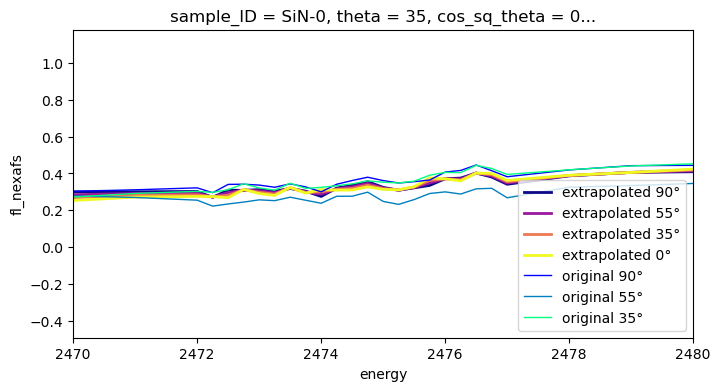

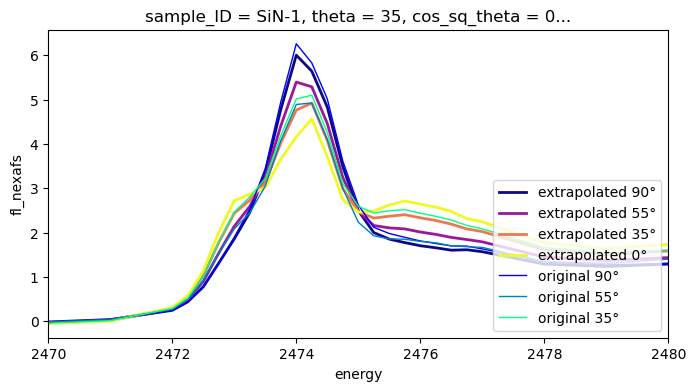

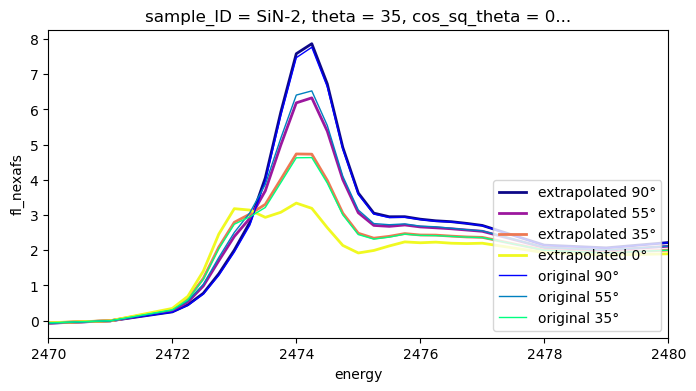

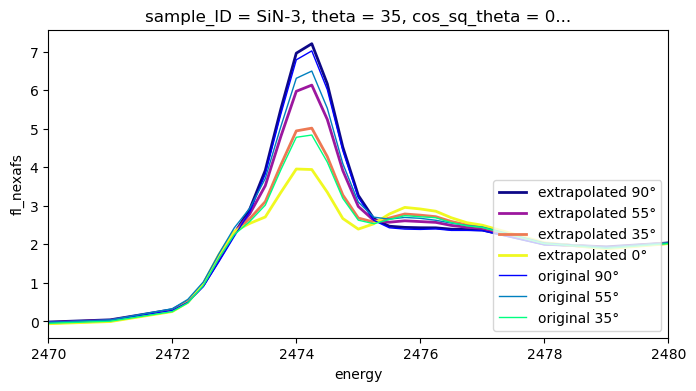

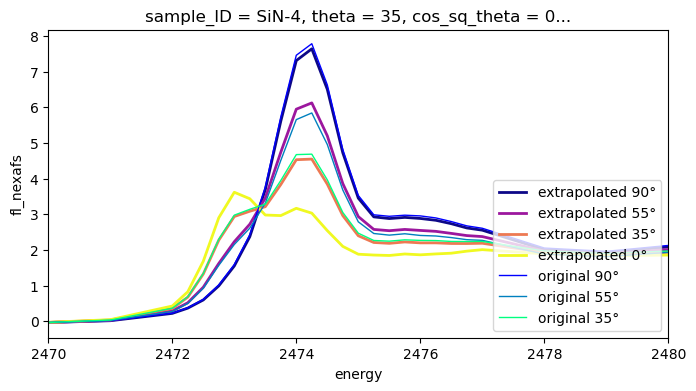

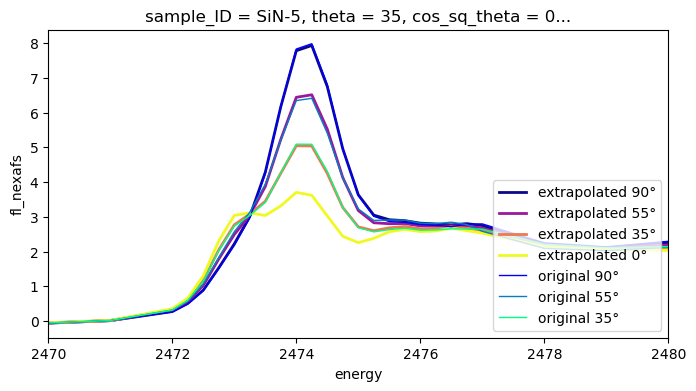

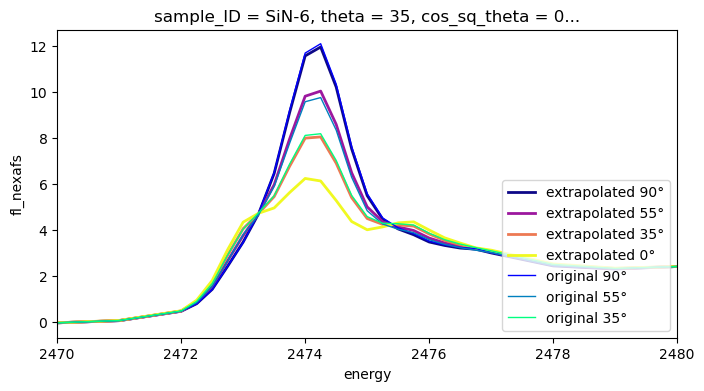

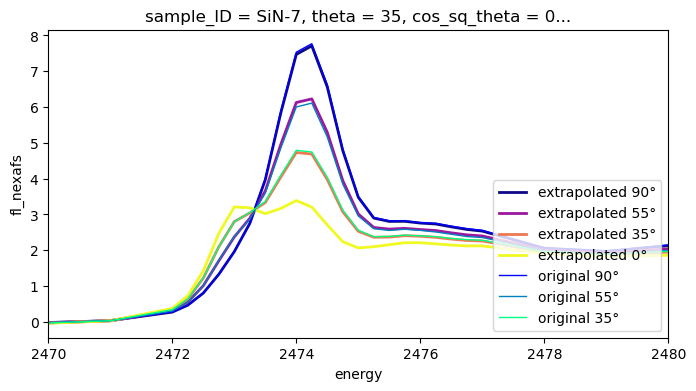

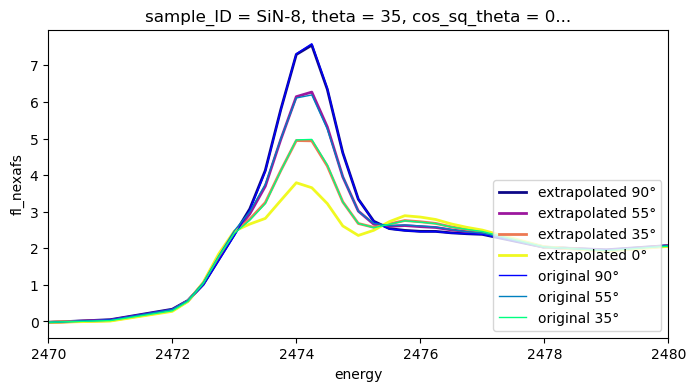

In [10]:
nexafs = nf_DA.swap_dims({'theta':'cos_sq_theta'})
nexafs_ep_rows = []
for sample_ID in nf_DA.sample_ID.values:
    DA = nf_DA.sel(sample_ID=sample_ID).copy()
    
    nexafs = DA.copy().swap_dims({'theta':'cos_sq_theta'}).squeeze()
    nexafs_fit = nexafs.polyfit('cos_sq_theta', 1)
    new_theta = np.append(DA.theta.values, 0)
    new_cos_sq_theta = np.round((np.cos(new_theta*np.pi/180))**2, 5)
    nexafs_ep = nf.evaluate_nexafs_fit(nexafs, nexafs_fit, new_cos_sq_theta, new_theta)   
    nexafs_ep = nexafs_ep.expand_dims({'sample_ID':[sample_ID]})
    nexafs_ep_rows.append(nexafs_ep['electron_yield'])
    
    
    fig, ax1 = plt.subplots(figsize=(8,4))
    #the xarray way of plotting
    colors = plt.cm.plasma(np.linspace(0,1,nexafs_ep.theta.size))
    colors2 = plt.cm.winter(np.linspace(0,1,nexafs.theta.size))
    for i, cos_sq_theta in enumerate(nexafs_ep.cos_sq_theta): 
        nexafs_ep.electron_yield.sel(cos_sq_theta=cos_sq_theta).plot(color = colors[i], lw = 2, label = f'extrapolated {nexafs_ep.theta[i].values}°')
    for i, cos_sq_theta in enumerate(nexafs.cos_sq_theta): 
        nexafs.sel(cos_sq_theta=cos_sq_theta).plot(color = colors2[i], lw = 1, label = f'original {nexafs.theta[i].values}°')
    # plt.title(nexafs.description)
    ax1.set_xlim(2470,2480)
    ax1.legend(loc='lower right')
    # plt.savefig(exportPath.joinpath(f'{nexafs_ep.name}_nexafs_theta_extrap.svg'))
    plt.show()
    plt.close('all')

nf_ep_DA = xr.concat(nexafs_ep_rows, dim='sample_ID')

In [ ]:
%matplotlib inline
plt.close('all')

# Plot all incident angles NEXAFS for each sample

# Select energy slice(s)
# e_slice = slice(None, None)
# e_slice = slice(2445, 2520)
# e_slice = slice(2470, 2495)
e_slice = slice(2470, 2480)


# colors = plt.cm.viridis_r(np.linspace(0.1,1,3))
colors = plt.cm.plasma_r(np.linspace(0.1,1,4))
for sample_ID in tqdm(nf_ep_DA.sample_ID.values[:]):
    fig, ax = plt.subplots(figsize=(5, 3), tight_layout=True, dpi=150)
    for i, theta in enumerate([0, 35, 55, 90]):
        # Plot    
        nf_ep_DA.swap_dims({'cos_sq_theta':'theta'}).sel(sample_ID=sample_ID, energy=e_slice, theta=theta).plot.line(ax=ax, label=f'{theta}°', color=colors[i])
                                                                        # linestyle='none', marker='.')

    ax.set_title(f'Extrapolated fluorescence NEXAFS: {sn[sample_ID]}')
    ax.set(ylabel=f'Intensity [arb. units]', xlabel='Energy [eV]')

    # ax.xaxis.set_minor_locator(MultipleLocator(5))
    
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    ax.xaxis.set_major_locator(MultipleLocator(2))
    ax.xaxis.grid(True, which='both')
    ax.legend(title='$\\theta$')

    savePath = basePath.joinpath('trexs_plots/2024C3/waxs_all/extrap_fl_nexafs_v1')
    savePath.mkdir(exist_ok=True)
    fig.savefig(savePath.joinpath(
        f'{sn_id[sample_ID]}_avg-roi-nexafs_energy-{e_slice.start}-{e_slice.stop}.png'), dpi=150)

    plt.show()
    plt.close('all')

## Extrapolate molecular tilt angle (make alpha = 0, perfect face-on)

### Fit NEXAFS peaks, we need to make the π* resonance peak go to zero at theta=90

In [ ]:
sn

In [ ]:
sample_ID = 'SiN-4'
ord_nexafs = nf_DA_ep.sel(sample_ID=sample_ID).sel(cos_sq_theta=0, method='nearest')
ext_nexafs = nf_DA_ep.sel(sample_ID=sample_ID).sel(cos_sq_theta=1, method='nearest')

In [ ]:
%matplotlib widget
plt.close('all')

energy_slice = slice(2470, 2480)
# energy_slice = slice(2470, None)

fig, ax = plt.subplots()
ord_nexafs.sel(energy=energy_slice).plot.line(ax=ax)
ext_nexafs.sel(energy=energy_slice).plot.line(ax=ax)
plt.show()
# plt.close('all')

### Try approach without fitting, just find minimum?

In [ ]:
def mse(cos_sq_theta, e_min, e_max, nexafs, nexafs_fit, targ):
    #compose new extrapolated nexafs based on proposed cos_sq_theta 
    nexafs_new = nf.evaluate_nexafs_fit(nexafs, nexafs_fit, [cos_sq_theta[0]], [0])
    #evaluate the difference in area between the extrapolated nexafs and the taget targ
    mse = (nf.int_area(e_min, e_max, nexafs_new.electron_yield)-targ)**2
    minval = nexafs_new.sel(energy = slice(e_min,e_max)).electron_yield.min().values
    if minval < 0.005: #impose penalty for negative absorbance values
        mse = 1E10*mse*np.abs(minval)

    # beyond the at 2474, minimum value should not dip below 1
    in_edge_minval = nexafs_new.sel(energy = slice(2474, 2476)).electron_yield.min().values
    if in_edge_minval < 1.7: #impose penalty for negative absorbance values
        mse = 1E10*mse*np.abs(in_edge_minval)
    return mse

In [ ]:
cossqtheta_o_rows = []
cossqtheta_e_rows = []
magic_nf_rows = []

e_min = 2471
e_max = 2473.8

for sample_ID in tqdm(nf_DA.sample_ID.values):
    DA = nf_ep_DA.sel(sample_ID=sample_ID).copy()
    
    nexafs = DA.copy()
    nexafs_fit = nexafs.polyfit('cos_sq_theta', 1)

    res_o = optimize.differential_evolution(mse, [(-1, 1)], args = (e_min, e_max, nexafs, nexafs_fit, 0), tol=1e-6)
    cossqtheta_o = float(res_o.x[0])
    cossqtheta_o_rows.append(cossqtheta_o)
    
    magic_nf = nf.evaluate_nexafs_fit(nexafs, nexafs_fit, [0.329], [55]).electron_yield
    magic_nf_rows.append(magic_nf)
    
    magic_int = nf.int_area(e_min, e_max, magic_nf)
    ord_int = nf.int_area(e_min, e_max, nf.evaluate_nexafs_fit(nexafs, nexafs_fit, [cossqtheta_o], [0]).electron_yield)
    e_targ = magic_int + 2*(magic_int-ord_int)

    # For perfectly face on, the extraordinary intensity should be exactly 3x magic intensity
    # This fit tends to be faster
    res_e = optimize.minimize(mse, 1, method='Nelder-Mead', args = (e_min, e_max, nexafs, nexafs_fit, e_targ), tol=1e-6)
    cossqtheta_e = float(res_e.x[0])    
    cossqtheta_e_rows.append(cossqtheta_e)

In [ ]:
cossqtheta_o_rows

In [ ]:
sorted(sn.keys())

In [ ]:
mol_fits

In [ ]:
# do this for a finely spaced values of theta...

nf_mol_DA_rows = []

sample_IDs = sorted(sn.keys())

for i, mol_fits in enumerate(zip(cossqtheta_o_rows, cossqtheta_e_rows)):
    mol_fits = list(mol_fits)

    num_fits = 100
    fine_mol_fits = np.linspace(mol_fits[0], mol_fits[1], num_fits)
    fine_theta = np.linspace(90, 0, num_fits)
    
    DA = nf_DA.sel(sample_ID=sample_IDs[i]).copy()
    magic_nf_DA = magic_nf_rows[i].swap_dims({'cos_sq_theta':'theta'})
    
    sample_name = sn[sample_IDs[i]]
    nexafs = DA.copy().swap_dims({'theta':'cos_sq_theta'}).squeeze()
    nexafs_fit = nexafs.polyfit('cos_sq_theta', 1)
    
    nexafs_mol = nf.evaluate_nexafs_fit(nexafs, nexafs_fit, fine_mol_fits, fine_theta)

    nf_mol_DA = nexafs_mol.electron_yield.swap_dims({'cos_sq_theta':'theta'}).rename('extrap_mol_nexafs')
    # nf_mol_DA = xr.concat([nf_mol_DA, magic_nf_DA], dim='theta').sortby('theta')
    # nf_mol_DA = nf_mol_DA.expand_dims({'sample_name': [sample_name]})
    nf_mol_DA = nf_mol_DA.expand_dims({'sample_ID': [sample_IDs[i]]})
    nf_mol_DA_rows.append(nf_mol_DA)


In [ ]:
%matplotlib inline
plt.close('all')

In [ ]:
whos PosixPath

In [ ]:
PM6_5CN_nf_mol_DA = xr.concat(nf_mol_DA_rows, dim='sample_ID').sel(sample_ID='SiN-4')
PM6_5CN_nf_mol_DA.to_dataset(name='extrapolated_nexafs')

In [ ]:
savePath = basePath.joinpath('local_data/trexs_nexafs_2024C3/waxs_all/extrap_nexafs_zarrs')
PM6_5CN_nf_mol_DA.to_dataset(name='extrapolated_nexafs').to_zarr(savePath.joinpath('PM6_5CN-CF_extrap_nexafs_v1.zarr'), mode='w')

In [ ]:
%matplotlib inline
plt.close('all')

colors = plt.cm.plasma(np.linspace(0,0.95,len(nf_mol_DA_rows[0].theta)))

energy_slice = slice(2470, 2480)
# energy_slice = slice(None, None)

for nf_mol_DA in nf_mol_DA_rows:
    fig, ax = plt.subplots()
    for i, theta_val in enumerate(nf_mol_DA.theta.values):
        nf_mol_DA.sel(energy=energy_slice, theta=theta_val).plot(color=colors[i], ax=ax)
    ax.set_title(sn[nf_mol_DA.sample_ID.values[0]])
    plt.show()
    # plt.close('all')

In [ ]:
nf_epmol_DA = xr.concat(nf_mol_DA_rows, dim='sample_ID')  #.sel(sample_ID='SiN-4')

In [ ]:
nf_epmol_DA

In [ ]:
%matplotlib inline
plt.close('all')

# Plot all incident angles NEXAFS for each sample

# Select energy slice(s)
# e_slice = slice(None, None)
e_slice = slice(2445, 2520)
# e_slice = slice(2470, 2495)
# e_slice = slice(2470, 2480)


# colors = plt.cm.viridis_r(np.linspace(0.1,1,3))
colors = plt.cm.plasma_r(np.linspace(0.1,1,4))
for sample_ID in tqdm(nf_epmol_DA.sample_ID.values[:]):
    fig, ax = plt.subplots(figsize=(5, 3), tight_layout=True, dpi=150)
    for i, theta in enumerate([0, 35, 55, 90]):
        # Plot    
        nf_epmol_DA.sel(sample_ID=sample_ID, energy=e_slice).sel(theta=theta, method='nearest').plot.line(ax=ax, label=f'{theta}°', color=colors[i])
                                                                        # linestyle='none', marker='.')

    ax.set_title(f'Extrapolated fluorescence NEXAFS: {sn[sample_ID]}')
    ax.set(ylabel=f'Intensity [arb. units]', xlabel='Energy [eV]')

    ax.xaxis.set_minor_locator(MultipleLocator(5))
    
    # ax.xaxis.set_minor_locator(MultipleLocator(1))
    # ax.xaxis.set_major_locator(MultipleLocator(2))
    ax.xaxis.grid(True, which='both')
    ax.legend(title='$\\theta$')

    savePath = basePath.joinpath('trexs_plots/2024C3/waxs_all/mol_nexafs_v1')
    savePath.mkdir(exist_ok=True)
    fig.savefig(savePath.joinpath(
        f'{sn_id[sample_ID]}_avg-roi-nexafs_energy-{e_slice.start}-{e_slice.stop}.png'), dpi=150)

    plt.show()
    plt.close('all')